# 07 — Empirical width bottleneck

Controlled endpoint-only experiment for configuration (c). The student architecture, corpus, optimizer, gauge updates, and evaluation protocol remain fixed while the active rank of the PCA teacher interface varies.

The notebook reports retained teacher energy, normalized cosine-Gram distortion, its rank-constrained lower bound, and downstream performance. The lower ranks are zero-padded to the native 384-dimensional student space before Procrustes alignment, so this sweep changes the retained teacher subspace rather than the student capacity.

In [1]:
# 1. Cấu hình thí nghiệm
from pathlib import Path

REPO_URL = "https://github.com/duncan-nguyen/embedding-kd.git"
AUTO_PULL_REPO, INSTALL_REQUIREMENTS = True, True
PAIR = "qwen3_0.6b_to_minilm_h384"
TRAIN_DATA_REL = Path("data/train_set/merged_3_data_5k_each.csv")
RANKS = [64, 128, 256, 384]
SEEDS = [42, 43, 44]
STUDENT_DIM = 384
BATCH_SIZE, EPOCHS, LR = 128, 5, 7e-5
MAX_LENGTH, NUM_WORKERS = 256, 2
GEOMETRY_ROWS, GEOMETRY_SEED = 2048, 0
EXECUTE, STOP_ON_ERROR, REQUIRE_COMPLETE = True, True, True
RENDER_FIGURE, COPY_TO_PAPER = True, False
SAVE_TO_GOOGLE_DRIVE = False
CUDA_VISIBLE_DEVICES = "0"
MAX_PARALLEL_JOBS, GPUS = 3, None
RUN_NAME_OVERRIDE = "analysis_width_bottleneck_qwen06b_minilm384_15k_v1"
RUN_NAME = RUN_NAME_OVERRIDE

assert RANKS == sorted(set(RANKS)) and min(RANKS) > 0
assert max(RANKS) == STUDENT_DIM
assert SEEDS and len(SEEDS) == len(set(SEEDS))
print(f"Pair: {PAIR}; ranks: {RANKS}; seeds: {SEEDS}")
print(f"Run: {RUN_NAME}")

Pair: qwen3_0.6b_to_minilm_h384; ranks: [64, 128, 256, 384]; seeds: [42, 43, 44]
Run: analysis_width_bottleneck_qwen06b_minilm384_15k_v1


In [2]:
# 2. Dùng repo hiện tại hoặc clone trên Colab; cài dependencies
import subprocess
import sys

cwd = Path.cwd().resolve()
PROJECT_DIR = next((p for p in (cwd, cwd.parent) if (p / "main.py").is_file()), None)
if PROJECT_DIR is None:
    clone_parent = Path("/content") if Path("/content").is_dir() else cwd
    PROJECT_DIR = clone_parent / "embedding-kd"
    if not PROJECT_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(PROJECT_DIR)], check=True)
    assert (PROJECT_DIR / "main.py").is_file(), f"Repo không hợp lệ: {PROJECT_DIR}"

tracked = subprocess.run(
    ["git", "-C", str(PROJECT_DIR), "status", "--porcelain", "--untracked-files=no"],
    check=True, capture_output=True, text=True,
).stdout.strip()
if AUTO_PULL_REPO and not tracked:
    subprocess.run(["git", "-C", str(PROJECT_DIR), "pull", "--ff-only"], check=True)
elif AUTO_PULL_REPO:
    print("[git] Bỏ qua pull vì repo có tracked changes.")
if INSTALL_REQUIREMENTS:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r", str(PROJECT_DIR / "requirements.txt")],
        check=True,
    )
git_head = subprocess.run(
    ["git", "-C", str(PROJECT_DIR), "rev-parse", "--short", "HEAD"],
    check=True, capture_output=True, text=True,
).stdout.strip()
sys.path[:0] = [str(PROJECT_DIR), str(PROJECT_DIR / "notebooks")]
print(f"Repo: {PROJECT_DIR} @ {git_head}")

Repo: /content/embedding-kd @ d9b6853


In [3]:
# 3. Output, GPU và dữ liệu
import torch

try:
    from google.colab import drive as colab_drive
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB and SAVE_TO_GOOGLE_DRIVE:
    colab_drive.mount("/content/drive")
    OUTPUT_BASE = Path("/content/drive/MyDrive/embedding-kd-runs")
else:
    OUTPUT_BASE = PROJECT_DIR / "runs"

RUN_ROOT = OUTPUT_BASE / RUN_NAME
CACHE_DIR = OUTPUT_BASE / "teacher_cache"
TRAIN_DATA = PROJECT_DIR / TRAIN_DATA_REL
assert TRAIN_DATA.is_file(), f"Thiếu training data: {TRAIN_DATA}"
if EXECUTE:
    assert torch.cuda.is_available(), "Hãy bật GPU runtime trước khi train."
    if hasattr(torch.cuda, "is_bf16_supported"):
        assert torch.cuda.is_bf16_supported(), "GPU phải hỗ trợ BF16."
for index in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(index)
    print(f"cuda:{index}: {props.name} ({props.total_memory / 2**30:.1f} GiB)")
RUN_ROOT.mkdir(parents=True, exist_ok=True)
print(f"Training data: {TRAIN_DATA}")
print(f"Output root: {RUN_ROOT}")

cuda:0: NVIDIA RTX PRO 6000 Blackwell Server Edition (95.0 GiB)
Training data: /content/embedding-kd/data/train_set/merged_3_data_5k_each.csv
Output root: /content/embedding-kd/runs/analysis_width_bottleneck_qwen06b_minilm384_15k_v1


In [4]:
# 4. Tạo plan — một endpoint-only run cho mỗi (rank, seed)
import shlex
from _analysis_common import PAIRS, collect_jobs, geoode_command, run_jobs

pair = PAIRS[PAIR]
run_root = RUN_ROOT
jobs = []
for rank in RANKS:
    for seed in SEEDS:
        run_dir = run_root / f"rank_{rank}" / f"seed_{seed}"
        extra = [
            "--projection_type", "pca",
            "--projection_rank", rank,
            "--gauge_align",
            "--gauge_rotation", "procrustes",
            "--gauge_refit_every", 1,
            "--lambda_end", 1,
            "--lambda_ctr", 0,
            "--lambda_topo", 0,
            "--no_eval_retrieval",
        ]
        jobs.append({
            "name": f"rank_{rank}/seed_{seed}",
            "rank": rank,
            "seed": seed,
            "run_dir": run_dir,
            "command": geoode_command(
                PROJECT_DIR, pair=pair, train_data=TRAIN_DATA, cache_dir=CACHE_DIR,
                run_dir=run_dir, seed=seed, batch_size=BATCH_SIZE, epochs=EPOCHS,
                learning_rate=LR, max_length=MAX_LENGTH, num_workers=NUM_WORKERS,
                extra=extra,
            ),
        })
print(f"Plan: {len(RANKS)} ranks × {len(SEEDS)} seeds = {len(jobs)} jobs")
for job in jobs:
    print(shlex.join(job["command"]))

Plan: 4 ranks × 3 seeds = 12 jobs
/usr/bin/python3 /content/embedding-kd/main.py --method geoode --train_data /content/embedding-kd/data/train_set/merged_3_data_5k_each.csv --student_model nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base --teacher_model Qwen/Qwen3-Embedding-0.6B --teacher_pooling last_token --batch_size 128 --epochs 5 --save_every 5 --lr 7e-05 --max_length 256 --seed 42 --num_workers 2 --eval_every 0 --pair_threshold_source test --cache_dir /content/embedding-kd/runs/teacher_cache --save_dir /content/embedding-kd/runs/analysis_width_bottleneck_qwen06b_minilm384_15k_v1/rank_64/seed_42 --no_wandb --student_pooling cls --projection_type pca --projection_rank 64 --gauge_align --gauge_rotation procrustes --gauge_refit_every 1 --lambda_end 1 --lambda_ctr 0 --lambda_topo 0 --no_eval_retrieval
/usr/bin/python3 /content/embedding-kd/main.py --method geoode --train_data /content/embedding-kd/data/train_set/merged_3_data_5k_each.csv --student_model nreimers/MiniLMv2-L6-H384-dis

In [7]:
# 5. Chạy jobs; final-test record là resume boundary
from IPython.display import display
from _analysis_common import prewarm_teacher_cache

if EXECUTE:
    prewarm_teacher_cache(
        PROJECT_DIR, pair=pair, train_data=TRAIN_DATA, cache_dir=CACHE_DIR,
        max_length=MAX_LENGTH, cuda_visible_devices=CUDA_VISIBLE_DEVICES,
    )
    display(run_jobs(
        PROJECT_DIR, jobs, cuda_visible_devices=CUDA_VISIBLE_DEVICES,
        stop_on_error=STOP_ON_ERROR, max_parallel=MAX_PARALLEL_JOBS, gpus=GPUS,
    ))
else:
    print("Dry run: đặt EXECUTE=True để chạy các job còn thiếu.")

[cache] already built: /content/embedding-kd/runs/teacher_cache/qwen-qwen3-embedding-0-6b__merged_3_data_5k_each__last_token__48d210faccc5.pt
[SKIP 1/12] rank_64/seed_42
[SKIP 2/12] rank_64/seed_43
[SKIP 3/12] rank_64/seed_44
[SKIP 4/12] rank_128/seed_42
[SKIP 5/12] rank_128/seed_43
[SKIP 6/12] rank_128/seed_44
[SKIP 7/12] rank_256/seed_42
[SKIP 8/12] rank_256/seed_43
[SKIP 9/12] rank_256/seed_44
[parallel] 3 job(s) over 3 slot(s): ['0', '0', '0']
[START 1/3] rank_384/seed_42 on GPU 0 (pid 24389) -> /content/embedding-kd/runs/analysis_width_bottleneck_qwen06b_minilm384_15k_v1/rank_384/seed_42/train.log
[START 2/3] rank_384/seed_43 on GPU 0 (pid 24390) -> /content/embedding-kd/runs/analysis_width_bottleneck_qwen06b_minilm384_15k_v1/rank_384/seed_43/train.log
[START 3/3] rank_384/seed_44 on GPU 0 (pid 24391) -> /content/embedding-kd/runs/analysis_width_bottleneck_qwen06b_minilm384_15k_v1/rank_384/seed_44/train.log
  [   0.0 min] gpu 0 rank_384/seed_42: 
  [   0.0 min] gpu 0 rank_384/seed

,name,rank,seed,run_dir,status,seconds,gpu,returncode
0,rank_64/seed_42,64,42,/content/embedding-kd/runs/analysis_width_bott...,skipped_complete,0.000000,NaN,NaN
1,rank_64/seed_43,64,43,/content/embedding-kd/runs/analysis_width_bott...,skipped_complete,0.000000,NaN,NaN
2,rank_64/seed_44,64,44,/content/embedding-kd/runs/analysis_width_bott...,skipped_complete,0.000000,NaN,NaN
3,rank_128/seed_42,128,42,/content/embedding-kd/runs/analysis_width_bott...,skipped_complete,0.000000,NaN,NaN
4,rank_128/seed_43,128,43,/content/embedding-kd/runs/analysis_width_bott...,skipped_complete,0.000000,NaN,NaN
5,rank_128/seed_44,128,44,/content/embedding-kd/runs/analysis_width_bott...,skipped_complete,0.000000,NaN,NaN
6,rank_256/seed_42,256,42,/content/embedding-kd/runs/analysis_width_bott...,skipped_complete,0.000000,NaN,NaN
7,rank_256/seed_43,256,43,/content/embedding-kd/runs/analysis_width_bott...,skipped_complete,0.000000,NaN,NaN
8,rank_256/seed_44,256,44,/content/embedding-kd/runs/analysis_width_bott...,skipped_complete,0.000000,NaN,NaN
9,rank_384/seed_42,384,42,/content/embedding-kd/runs/analysis_width_bott...,complete,90.024922,0,0.0


In [8]:
# 6. Tổng hợp geometry và downstream performance
import numpy as np
import pandas as pd
import torch.nn.functional as F
from _analysis_common import load_teacher_cache, teacher_cache_path
from src import structural_audit as audit

results = collect_jobs(jobs)
results.to_csv(run_root / "width_bottleneck_by_run.csv", index=False)
done = results.query("status == 'done'").copy()
expected = {rank: len(SEEDS) for rank in RANKS}
counts = done.groupby("rank").size().to_dict() if not done.empty else {}
if REQUIRE_COMPLETE and counts != expected:
    raise RuntimeError(f"Incomplete rank grid: got {counts}, expected {expected}")

score_summary = done.groupby("rank", as_index=False).agg(
    avg_iod_mean=("avg_iod", "mean"), avg_iod_std=("avg_iod", "std"),
    avg_ood_mean=("avg_ood", "mean"), avg_ood_std=("avg_ood", "std"),
    avg_mean=("avg_all", "mean"), avg_std=("avg_all", "std"),
    n=("avg_all", "count"),
)

cache_path = teacher_cache_path(
    PROJECT_DIR, CACHE_DIR, pair=pair, train_data=TRAIN_DATA, max_length=MAX_LENGTH,
)
teacher, _ = load_teacher_cache(cache_path)
rng = np.random.default_rng(GEOMETRY_SEED)
indices = np.sort(rng.choice(len(teacher), min(GEOMETRY_ROWS, len(teacher)), replace=False))
teacher_sample = F.normalize(teacher[torch.as_tensor(indices)].float(), dim=-1)
teacher_gram = teacher_sample @ teacher_sample.T
gram_scale = teacher_gram.square().sum().clamp_min(1e-12)
singular_values = torch.linalg.svdvals(teacher_sample)
spectrum_scale = singular_values.pow(4).sum().clamp_min(1e-12)

geometry_rows = []
for rank in RANKS:
    job = next(job for job in jobs if job["rank"] == rank and job["seed"] == SEEDS[0])
    saved = audit.load_saved_projection(job["run_dir"] / "teacher_projection.pt")
    targets = audit.targets_from_saved(teacher_sample, saved)
    target_gram = targets @ targets.T
    gram_distortion = float((teacher_gram - target_gram).square().sum() / gram_scale)
    lower_bound = float(singular_values[rank:].pow(4).sum() / spectrum_scale)
    if gram_distortion + 1e-5 < lower_bound:
        raise RuntimeError(
            f"Rank-{rank} distortion {gram_distortion:.6f} violates lower bound {lower_bound:.6f}"
        )
    geometry_rows.append({
        "rank": rank,
        "retained_energy": float(saved["explained_energy"]),
        "gram_lower_bound": lower_bound,
        "target_gram_distortion": gram_distortion,
    })
geometry_summary = pd.DataFrame(geometry_rows)
summary = geometry_summary.merge(score_summary, on="rank", validate="one_to_one")
summary.to_csv(run_root / "width_bottleneck_summary.csv", index=False)
display(summary.round(5))

Loading cached embeddings from: /content/embedding-kd/runs/teacher_cache/qwen-qwen3-embedding-0-6b__merged_3_data_5k_each__last_token__48d210faccc5.pt
Loaded embeddings: (14760, 1024)


,rank,retained_energy,gram_lower_bound,target_gram_distortion,avg_iod_mean,avg_iod_std,avg_ood_mean,avg_ood_std,avg_mean,avg_std,n
0,64,0.59320,0.00281,0.06797,0.65576,0.00119,0.76067,0.00066,0.72570,0.00069,3
1,128,0.73936,0.00095,0.02132,0.66951,0.00126,0.77174,0.00062,0.73766,0.00078,3
2,256,0.87279,0.00018,0.00443,0.67536,0.00051,0.77544,0.00027,0.74208,0.00015,3
3,384,0.92840,0.00004,0.00086,0.67664,0.00081,0.77573,0.00023,0.74270,0.00040,3


/content/embedding-kd/runs/analysis_width_bottleneck_qwen06b_minilm384_15k_v1/figures/width_bottleneck.pdf
/content/embedding-kd/runs/analysis_width_bottleneck_qwen06b_minilm384_15k_v1/figures/width_bottleneck.png


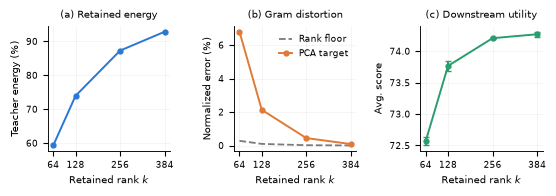

655

In [9]:
# 7. Figure paper-ready và manifest
import json
import shutil
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 7.2,
    "axes.titlesize": 7.5, "axes.labelsize": 7.2,
    "xtick.labelsize": 6.6, "ytick.labelsize": 6.6,
    "axes.linewidth": 0.65, "pdf.fonttype": 42, "ps.fonttype": 42,
    "savefig.dpi": 300,
})
figure_files = []
if RENDER_FIGURE:
    fig, axes = plt.subplots(1, 3, figsize=(5.5, 2.05))
    x = summary["rank"].to_numpy()
    axes[0].plot(x, 100 * summary["retained_energy"], "o-", color="#2A78D6", lw=1.4, ms=3.5)
    axes[0].set_title("(a) Retained energy")
    axes[0].set_ylabel("Teacher energy (%)")

    axes[1].plot(x, 100 * summary["gram_lower_bound"], "--", color="#7A7A7A", lw=1.3, label="Rank floor")
    axes[1].plot(x, 100 * summary["target_gram_distortion"], "o-", color="#E07A35", lw=1.4, ms=3.5, label="PCA target")
    axes[1].set_title("(b) Gram distortion")
    axes[1].set_ylabel("Normalized error (%)")
    axes[1].legend(frameon=False, fontsize=6.2, handlelength=1.5)

    axes[2].errorbar(
        x, 100 * summary["avg_mean"], yerr=100 * summary["avg_std"],
        fmt="o-", color="#2A9D6F", lw=1.4, ms=3.5, capsize=2,
    )
    axes[2].set_title("(c) Downstream utility")
    axes[2].set_ylabel("Avg. score")

    for axis in axes:
        axis.set_xlabel(r"Retained rank $k$")
        axis.set_xticks(RANKS)
        axis.grid(alpha=0.18, linewidth=0.5)
        axis.spines[["top", "right"]].set_visible(False)
    fig.subplots_adjust(left=0.09, right=0.99, bottom=0.23, top=0.84, wspace=0.52)
    figure_dir = run_root / "figures"
    figure_dir.mkdir(parents=True, exist_ok=True)
    for suffix in ("pdf", "png"):
        path = figure_dir / f"width_bottleneck.{suffix}"
        fig.savefig(path, facecolor="white")
        figure_files.append(path)
        print(path)
    plt.show()
    if COPY_TO_PAPER:
        paper_dir = PROJECT_DIR / "docs" / "latex_iclr" / "figures"
        for path in figure_files:
            shutil.copy2(path, paper_dir / path.name)

manifest = {
    "git_head": git_head, "pair": PAIR, "train_data": str(TRAIN_DATA_REL),
    "ranks": RANKS, "seeds": SEEDS, "student_dim": STUDENT_DIM,
    "batch_size": BATCH_SIZE, "epochs": EPOCHS, "learning_rate": LR,
    "objective": "endpoint_only", "gauge_refit_every": 1,
    "geometry_rows": len(teacher_sample), "geometry_seed": GEOMETRY_SEED,
    "figures": [str(path) for path in figure_files],
}
(run_root / "experiment_manifest.json").write_text(
    json.dumps(manifest, indent=2), encoding="utf-8",
)

In [11]:
# 8. Không train thêm — observed width distortion trên ba configuration
import gc
from transformers import AutoTokenizer

REFERENCE_ROOTS = [
    # Ưu tiên đúng checkpoints của main table trên H200.
    OUTPUT_BASE / "main_results_talas15k_h200_gpu67_20260904-082000",
    # Fallback nếu notebook 04 đã được chạy trong cùng runtime/storage.
    OUTPUT_BASE / "analysis_layerwise_all_pairs_talas15k_v1",
]
drive_runs = Path("/content/drive/MyDrive/embedding-kd-runs")
if drive_runs.is_dir():
    REFERENCE_ROOTS = [
        drive_runs / "main_results_talas15k_h200_gpu67_20260904-082000",
        drive_runs / "analysis_layerwise_all_pairs_talas15k_v1",
        *REFERENCE_ROOTS,
    ]
REFERENCE_PAIRS = [
    "qwen3_4b_to_bert_base",
    "bge_m3_to_minilm_h768",
    "qwen3_0.6b_to_minilm_h384",
]
REFERENCE_SEEDS = [42, 43, 44]
REFERENCE_DIMS = {
    "qwen3_4b_to_bert_base": 768,
    "bge_m3_to_minilm_h768": 768,
    "qwen3_0.6b_to_minilm_h384": 384,
}
ANALYSIS_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

corpus = pd.read_csv(TRAIN_DATA)
text_column = next(
    (column for column in ("premise", "sentence1", "text") if column in corpus),
    None,
)
if text_column is None:
    raise ValueError(f"Không tìm thấy text column trong {list(corpus.columns)}")
corpus_texts = corpus[text_column].astype(str).tolist()
rng = np.random.default_rng(GEOMETRY_SEED)
reference_indices = np.sort(
    rng.choice(len(corpus_texts), min(GEOMETRY_ROWS, len(corpus_texts)), replace=False)
)
reference_texts = [corpus_texts[index] for index in reference_indices]

def resolve_reference_dir(pair_key, seed):
    layouts = [
        Path(pair_key) / "geoode" / f"seed_{seed}",
        Path("runs") / pair_key / "ours" / f"seed_{seed}",
    ]
    for root in dict.fromkeys(REFERENCE_ROOTS):
        for relative in layouts:
            candidate = root / relative
            if (candidate / f"checkpoint_epoch_{EPOCHS}.pt").is_file():
                return candidate
    return None

reference_dirs = {
    (pair_key, seed): resolve_reference_dir(pair_key, seed)
    for pair_key in REFERENCE_PAIRS for seed in REFERENCE_SEEDS
}
missing = [key for key, directory in reference_dirs.items() if directory is None]
missing_projection = [
    pair_key for pair_key in REFERENCE_PAIRS
    if reference_dirs[(pair_key, REFERENCE_SEEDS[0])] is not None
    and not (reference_dirs[(pair_key, REFERENCE_SEEDS[0])] / "teacher_projection.pt").is_file()
]
if missing or missing_projection:
    missing_text = ", ".join(f"{pair}/seed_{seed}" for pair, seed in missing)
    projection_text = ", ".join(missing_projection)
    searched = "\n".join(f"  - {root}" for root in dict.fromkeys(REFERENCE_ROOTS))
    raise FileNotFoundError(
        "Không tìm thấy đủ GATE-KD checkpoints 15K để đo final-student distortion.\n"
        f"Missing checkpoints: {missing_text or 'none'}\n"
        f"Missing projections: {projection_text or 'none'}\n"
        f"Đã tìm trong:\n{searched}\n"
        "Các files này là kết quả training, nên không thể tái tạo bằng zero-padding "
        "hoặc analysis-only. Hãy restore canonical H200 run hoặc resume các ours jobs "
        "còn thiếu trong notebook 04."
    )

display(pd.DataFrame([
    {"pair": pair_key, "seed": seed, "checkpoint_dir": str(reference_dirs[(pair_key, seed)])}
    for pair_key in REFERENCE_PAIRS for seed in REFERENCE_SEEDS
]))

observed_rows = []
for pair_key in REFERENCE_PAIRS:
    pair_spec = PAIRS[pair_key]
    student_dim = REFERENCE_DIMS[pair_key]
    cache_path = teacher_cache_path(
        PROJECT_DIR, CACHE_DIR, pair=pair_spec, train_data=TRAIN_DATA,
        max_length=MAX_LENGTH,
    )
    teacher_cache, _ = load_teacher_cache(cache_path)
    teacher_cpu = F.normalize(
        teacher_cache[torch.as_tensor(reference_indices)].float(), dim=-1
    )
    teacher_device = teacher_cpu.to(ANALYSIS_DEVICE)
    teacher_gram = teacher_device @ teacher_device.T
    gram_scale = teacher_gram.square().sum().clamp_min(1e-12)
    singular_values = torch.linalg.svdvals(teacher_device)
    rank_floor = float(
        singular_values[student_dim:].pow(4).sum()
        / singular_values.pow(4).sum().clamp_min(1e-12)
    )

    projection_path = (
        reference_dirs[(pair_key, REFERENCE_SEEDS[0])] / "teacher_projection.pt"
    )
    saved = audit.load_saved_projection(projection_path)
    target = audit.targets_from_saved(teacher_cpu, saved).to(ANALYSIS_DEVICE)
    target_gram = target @ target.T
    target_distortion = float(
        (teacher_gram - target_gram).square().sum() / gram_scale
    )

    tokenizer = AutoTokenizer.from_pretrained(pair_spec["student"])
    student_distortions = []
    for seed in REFERENCE_SEEDS:
        checkpoint = reference_dirs[(pair_key, seed)] / f"checkpoint_epoch_{EPOCHS}.pt"
        model = audit.load_student(
            pair_spec["student"], checkpoint, device=ANALYSIS_DEVICE
        )
        student = audit.encode_texts(
            model, tokenizer, reference_texts, device=ANALYSIS_DEVICE,
            pooling=pair_spec["student_pooling"], batch_size=128,
            max_length=MAX_LENGTH, progress=True,
        )["final"]
        student = F.normalize(student.float(), dim=-1).to(ANALYSIS_DEVICE)
        student_gram = student @ student.T
        student_distortions.append(float(
            (teacher_gram - student_gram).square().sum() / gram_scale
        ))
        del model, student, student_gram
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if target_distortion + 1e-5 < rank_floor:
        raise RuntimeError(f"PCA target violates the rank floor for {pair_key}")
    if min(student_distortions) + 1e-5 < rank_floor:
        raise RuntimeError(f"Student violates the rank floor for {pair_key}")
    observed_rows.append({
        "pair": pair_key, "student_dim": student_dim,
        "rank_floor": rank_floor,
        "pca_target_distortion": target_distortion,
        "student_distortion_mean": float(np.mean(student_distortions)),
        "student_distortion_std": float(np.std(student_distortions, ddof=1)),
    })
    del teacher_cache, teacher_cpu, teacher_device, teacher_gram, target, target_gram
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

observed = pd.DataFrame(observed_rows)
observed.to_csv(run_root / "observed_width_distortion_all_pairs.csv", index=False)
display(observed.round(5))

if RENDER_FIGURE:
    positions = np.arange(len(observed))
    width = 0.24
    fig, axis = plt.subplots(figsize=(5.5, 2.55))
    axis.bar(positions - width, 100 * observed["rank_floor"], width,
             color="#7A7A7A", label="Rank floor")
    axis.bar(positions, 100 * observed["pca_target_distortion"], width,
             color="#E07A35", label="PCA target")
    axis.bar(positions + width, 100 * observed["student_distortion_mean"], width,
             yerr=100 * observed["student_distortion_std"], capsize=2,
             color="#2A9D6F", label="GATE-KD student")
    axis.set_ylabel("Normalized Gram distortion (%)")
    axis.set_xticks(positions, ["(a)", "(b)", "(c)"])
    axis.set_xlabel("Teacher–student configuration")
    axis.grid(axis="y", alpha=0.18, linewidth=0.5)
    axis.spines[["top", "right"]].set_visible(False)
    axis.legend(frameon=False, ncols=3, fontsize=6.4, loc="upper center")
    fig.subplots_adjust(left=0.13, right=0.99, bottom=0.22, top=0.96)
    figure_dir = run_root / "figures"
    figure_dir.mkdir(parents=True, exist_ok=True)
    observed_files = []
    for suffix in ("pdf", "png"):
        path = figure_dir / f"observed_width_distortion_all_pairs.{suffix}"
        fig.savefig(path, facecolor="white")
        observed_files.append(path)
        print(path)
    plt.show()
    if COPY_TO_PAPER:
        paper_dir = PROJECT_DIR / "docs" / "latex_iclr" / "figures"
        for path in observed_files:
            shutil.copy2(path, paper_dir / path.name)

FileNotFoundError: Không tìm thấy đủ GATE-KD checkpoints 15K để đo final-student distortion.
Missing checkpoints: bge_m3_to_minilm_h768/seed_42, bge_m3_to_minilm_h768/seed_43, bge_m3_to_minilm_h768/seed_44, qwen3_0.6b_to_minilm_h384/seed_42, qwen3_0.6b_to_minilm_h384/seed_43
Missing projections: none
Đã tìm trong:
  - /content/embedding-kd/runs/main_results_talas15k_h200_gpu67_20260904-082000
  - /content/embedding-kd/runs/analysis_layerwise_all_pairs_talas15k_v1
Các files này là kết quả training, nên không thể tái tạo bằng zero-padding hoặc analysis-only. Hãy restore canonical H200 run hoặc resume các ours jobs còn thiếu trong notebook 04.